# Snow Pole Dataset Exploration

This notebook explores the LiDAR and RGB datasets for snow pole detection. We'll visualize the data, analyze label distributions, and gain insights into the dataset characteristics.

In [4]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
import random
import seaborn as sns

# Add parent directory to path to import from src
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Dataset Structure

Let's start by exploring the structure of the datasets.

In [5]:
# Dataset paths
DATA_ROOT = Path('/datasets/tdt4265/ad/open/Poles')

# LiDAR paths
LIDAR_ROOT = DATA_ROOT / 'lidar'
LIDAR_IMG_DIR = LIDAR_ROOT / 'combined_color'
LIDAR_LABEL_DIR = LIDAR_ROOT / 'labels'

# RGB paths
RGB_ROOT = DATA_ROOT / 'rgb'
RGB_IMG_DIR = RGB_ROOT / 'images'
RGB_LABEL_DIR = RGB_ROOT / 'labels'

# Check directory structure
print(f"LiDAR directory exists: {LIDAR_ROOT.exists()}")
print(f"RGB directory exists: {RGB_ROOT.exists()}")
print(f"LiDAR images directory exists: {LIDAR_IMG_DIR.exists()}")
print(f"RGB images directory exists: {RGB_IMG_DIR.exists()}")

# List subdirectories
print("\nLiDAR subdirectories:")
for d in LIDAR_ROOT.iterdir():
    if d.is_dir():
        print(f"  {d.name}/")

print("\nRGB subdirectories:")
for d in RGB_ROOT.iterdir():
    if d.is_dir():
        print(f"  {d.name}/")

LiDAR directory exists: True
RGB directory exists: True
LiDAR images directory exists: True
RGB images directory exists: True

LiDAR subdirectories:
  labels/
  combined_color/

RGB subdirectories:
  labels/
  images/


## 2. Dataset Statistics

Let's analyze the dataset statistics - number of images, splits, etc.

In [6]:
def count_images_and_labels(img_dir, label_dir):
    """Count number of images and labels in each split"""
    # Get splits (train, valid, test)
    splits = [d for d in img_dir.iterdir() if d.is_dir()]
    
    stats = {}
    for split_dir in splits:
        split_name = split_dir.name
        
        # Count images
        image_files = list(split_dir.glob('*.jpg')) + list(split_dir.glob('*.jpeg')) + list(split_dir.glob('*.png')) + list(split_dir.glob('*.PNG'))
        num_images = len(image_files)
        
        # Count label files
        label_files = list((label_dir / split_name).glob('*.txt'))
        num_labels = len(label_files)
        
        # Count total annotations
        total_boxes = 0
        for label_file in label_files:
            with open(label_file, 'r') as f:
                total_boxes += len(f.readlines())
        
        stats[split_name] = {
            'images': num_images,
            'labels': num_labels,
            'annotations': total_boxes,
            'avg_annotations_per_image': total_boxes / max(1, num_images)
        }
    
    return stats

# Count for LiDAR dataset
try:
    lidar_stats = count_images_and_labels(LIDAR_IMG_DIR, LIDAR_LABEL_DIR)
    print("LiDAR Dataset Statistics:")
    print(pd.DataFrame(lidar_stats).T)
except Exception as e:
    print(f"Error analyzing LiDAR dataset: {e}")

# Count for RGB dataset
try:
    rgb_stats = count_images_and_labels(RGB_IMG_DIR, RGB_LABEL_DIR)
    print("\nRGB Dataset Statistics:")
    print(pd.DataFrame(rgb_stats).T)
except Exception as e:
    print(f"Error analyzing RGB dataset: {e}")

LiDAR Dataset Statistics:
       images  labels  annotations  avg_annotations_per_image
train  1367.0  1367.0       2754.0                   2.014631
test    197.0     0.0          0.0                   0.000000
valid   390.0   390.0        789.0                   2.023077

RGB Dataset Statistics:
       images  labels  annotations  avg_annotations_per_image
train   322.0   322.0        392.0                   1.217391
test     46.0     0.0          0.0                   0.000000
valid    92.0    92.0        113.0                   1.228261


## 3. Visualize Sample Images with Annotations

Let's visualize some sample images with their bounding box annotations.

In [7]:
def plot_image_with_boxes(image_path, label_path, title=''):
    """Plot image with bounding boxes"""
    # Read image
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Get image dimensions
    height, width, _ = img.shape
    
    # Create figure and plot image
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    
    # Check if label file exists
    if not os.path.exists(label_path):
        plt.title(f"{title} (No labels found)")
        plt.axis('off')
        return
    
    # Read and plot bounding boxes
    with open(label_path, 'r') as f:
        for line in f:
            data = line.strip().split()
            class_id = int(data[0])
            # YOLO format: class_id, x_center, y_center, width, height (normalized)
            x_center, y_center, w, h = map(float, data[1:5])
            
            # Convert normalized coordinates to pixel coordinates
            x_center *= width
            y_center *= height
            w *= width
            h *= height
            
            # Calculate box coordinates
            x1 = int(x_center - w/2)
            y1 = int(y_center - h/2)
            x2 = int(x_center + w/2)
            y2 = int(y_center + h/2)
            
            # Plot rectangle
            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='red', linewidth=2)
            plt.gca().add_patch(rect)
            
            # Add label
            plt.text(x1, y1-5, f'Pole {class_id}', color='red', fontsize=10, 
                     bbox=dict(facecolor='white', alpha=0.7))
    
    plt.title(title)
    plt.axis('off')


### 3.1 LiDAR Sample Images

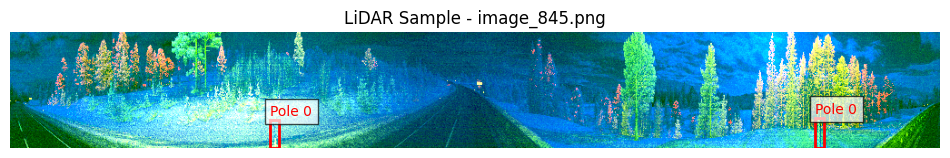

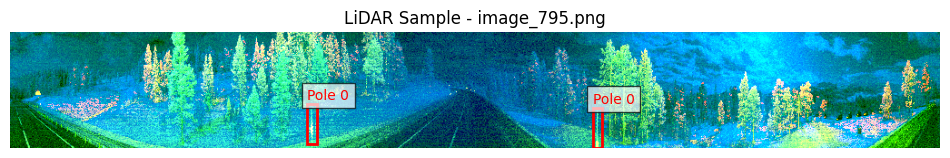

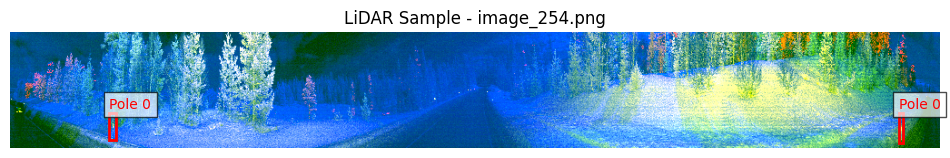

In [8]:
# Get random samples from LiDAR train set
try:
    lidar_train_img_dir = LIDAR_IMG_DIR / 'train'
    lidar_train_label_dir = LIDAR_LABEL_DIR / 'train'
    
    if lidar_train_img_dir.exists() and lidar_train_label_dir.exists():
        # Get list of images
        lidar_image_files = list(lidar_train_img_dir.glob('*.jpg')) + list(lidar_train_img_dir.glob('*.jpeg')) + list(lidar_train_img_dir.glob('*.png'))
        
        # Sample 3 random images
        if lidar_image_files:
            sample_images = random.sample(lidar_image_files, min(3, len(lidar_image_files)))
            
            for img_path in sample_images:
                # Construct label path
                label_path = lidar_train_label_dir / f"{img_path.stem}.txt"
                plot_image_with_boxes(img_path, label_path, f"LiDAR Sample - {img_path.name}")
        else:
            print("No LiDAR images found")
    else:
        print(f"LiDAR train directories not found. Please check paths.")
except Exception as e:
    print(f"Error visualizing LiDAR samples: {e}")

### 3.2 RGB Sample Images

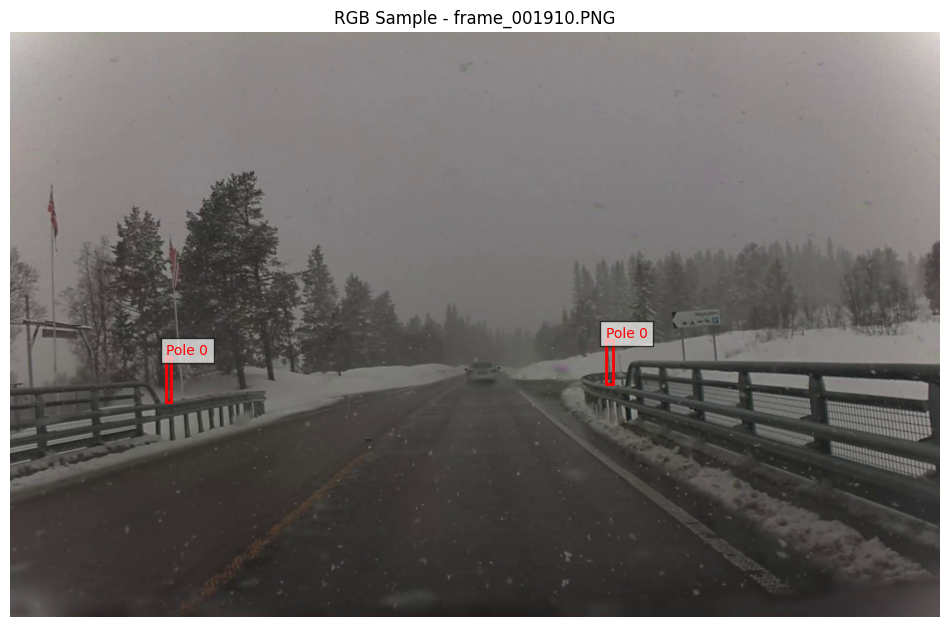

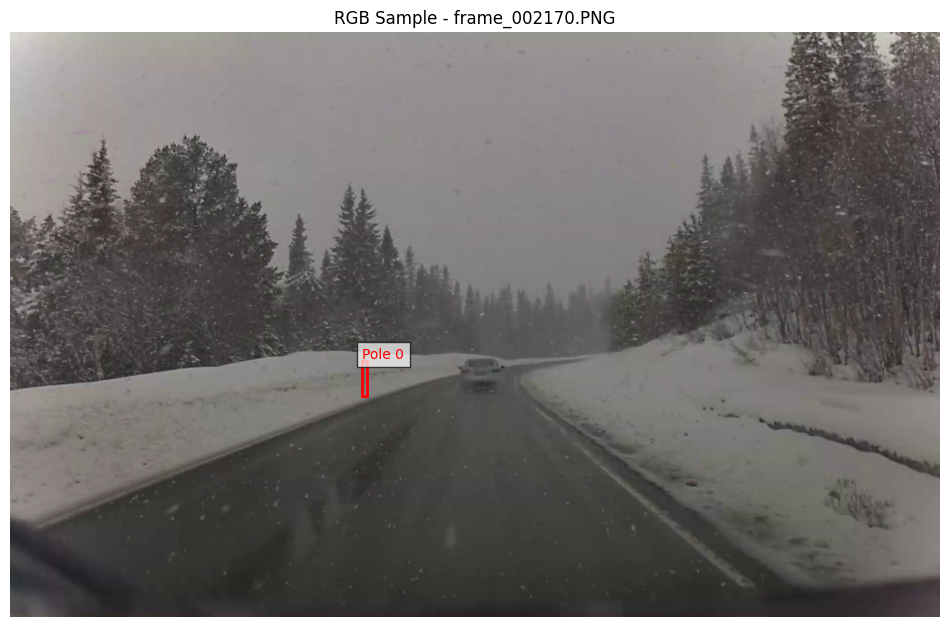

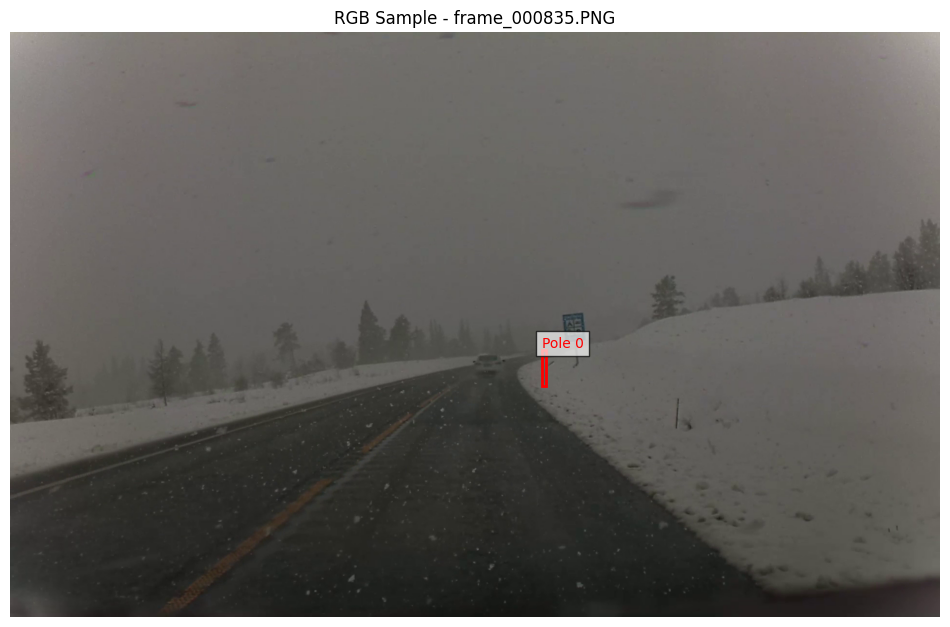

In [9]:
# Get random samples from RGB train set
try:
    rgb_train_img_dir = RGB_IMG_DIR / 'train'
    rgb_train_label_dir = RGB_LABEL_DIR / 'train'
    
    if rgb_train_img_dir.exists() and rgb_train_label_dir.exists():
        # Get list of images
        rgb_image_files = list(rgb_train_img_dir.glob('*.jpg')) + list(rgb_train_img_dir.glob('*.jpeg')) + list(rgb_train_img_dir.glob('*.png')) + list(rgb_train_img_dir.glob('*.PNG'))
        
        # Sample 3 random images
        if rgb_image_files:
            sample_images = random.sample(rgb_image_files, min(3, len(rgb_image_files)))
            
            for img_path in sample_images:
                # Construct label path
                label_path = rgb_train_label_dir / f"{img_path.stem}.txt"
                plot_image_with_boxes(img_path, label_path, f"RGB Sample - {img_path.name}")
        else:
            print("No RGB images found")
    else:
        print(f"RGB train directories not found. Please check paths.")
except Exception as e:
    print(f"Error visualizing RGB samples: {e}")

## 4. Analyze Bounding Box Distributions

Let's analyze the distribution of bounding box sizes, aspect ratios, and positions.

In [10]:
def collect_bbox_stats(label_dir):
    """Collect bounding box statistics from labels"""
    # Create lists to store data
    widths = []
    heights = []
    areas = []
    aspect_ratios = []
    x_centers = []
    y_centers = []
    
    # Process all label files in directory
    if not label_dir.exists():
        return pd.DataFrame()
    
    # Process all splits
    for split_dir in [d for d in label_dir.iterdir() if d.is_dir()]:
        split_name = split_dir.name
        label_files = list(split_dir.glob('*.txt'))
        
        for label_file in label_files:
            with open(label_file, 'r') as f:
                for line in f:
                    data = line.strip().split()
                    # YOLO format: class_id, x_center, y_center, width, height (normalized)
                    x_center, y_center, width, height = map(float, data[1:5])
                    
                    # Store data
                    widths.append(width)
                    heights.append(height)
                    areas.append(width * height)
                    aspect_ratios.append(width / height if height > 0 else 0)
                    x_centers.append(x_center)
                    y_centers.append(y_center)
    
    # Create DataFrame
    data = {
        'width': widths,
        'height': heights,
        'area': areas,
        'aspect_ratio': aspect_ratios,
        'x_center': x_centers,
        'y_center': y_centers
    }
    
    return pd.DataFrame(data)

# Collect statistics
try:
    lidar_bbox_stats = collect_bbox_stats(LIDAR_LABEL_DIR)
    rgb_bbox_stats = collect_bbox_stats(RGB_LABEL_DIR)
    
    # Print summary statistics
    if not lidar_bbox_stats.empty:
        print("LiDAR Bounding Box Statistics:")
        print(lidar_bbox_stats.describe())
    
    if not rgb_bbox_stats.empty:
        print("\nRGB Bounding Box Statistics:")
        print(rgb_bbox_stats.describe())
except Exception as e:
    print(f"Error analyzing bounding box statistics: {e}")

LiDAR Bounding Box Statistics:
             width       height         area  aspect_ratio     x_center  \
count  3543.000000  3543.000000  3543.000000   3543.000000  3543.000000   
mean      0.007255     0.233397     0.001798      0.033296     0.501118   
std       0.002282     0.079975     0.001022      0.022059     0.297365   
min       0.001953     0.003906     0.000017      0.009615     0.027832   
25%       0.005371     0.171875     0.000996      0.025735     0.278320   
50%       0.007324     0.226562     0.001656      0.031250     0.436523   
75%       0.008789     0.285156     0.002428      0.037500     0.760742   
max       0.020508     0.539062     0.008972      1.125000     0.985352   

          y_center  
count  3543.000000  
mean      0.790126  
std       0.084203  
min       0.566406  
25%       0.722656  
50%       0.804688  
75%       0.859375  
max       0.976562  

RGB Bounding Box Statistics:
            width      height        area  aspect_ratio    x_center  \
cou

### 4.1 Bounding Box Size Distribution

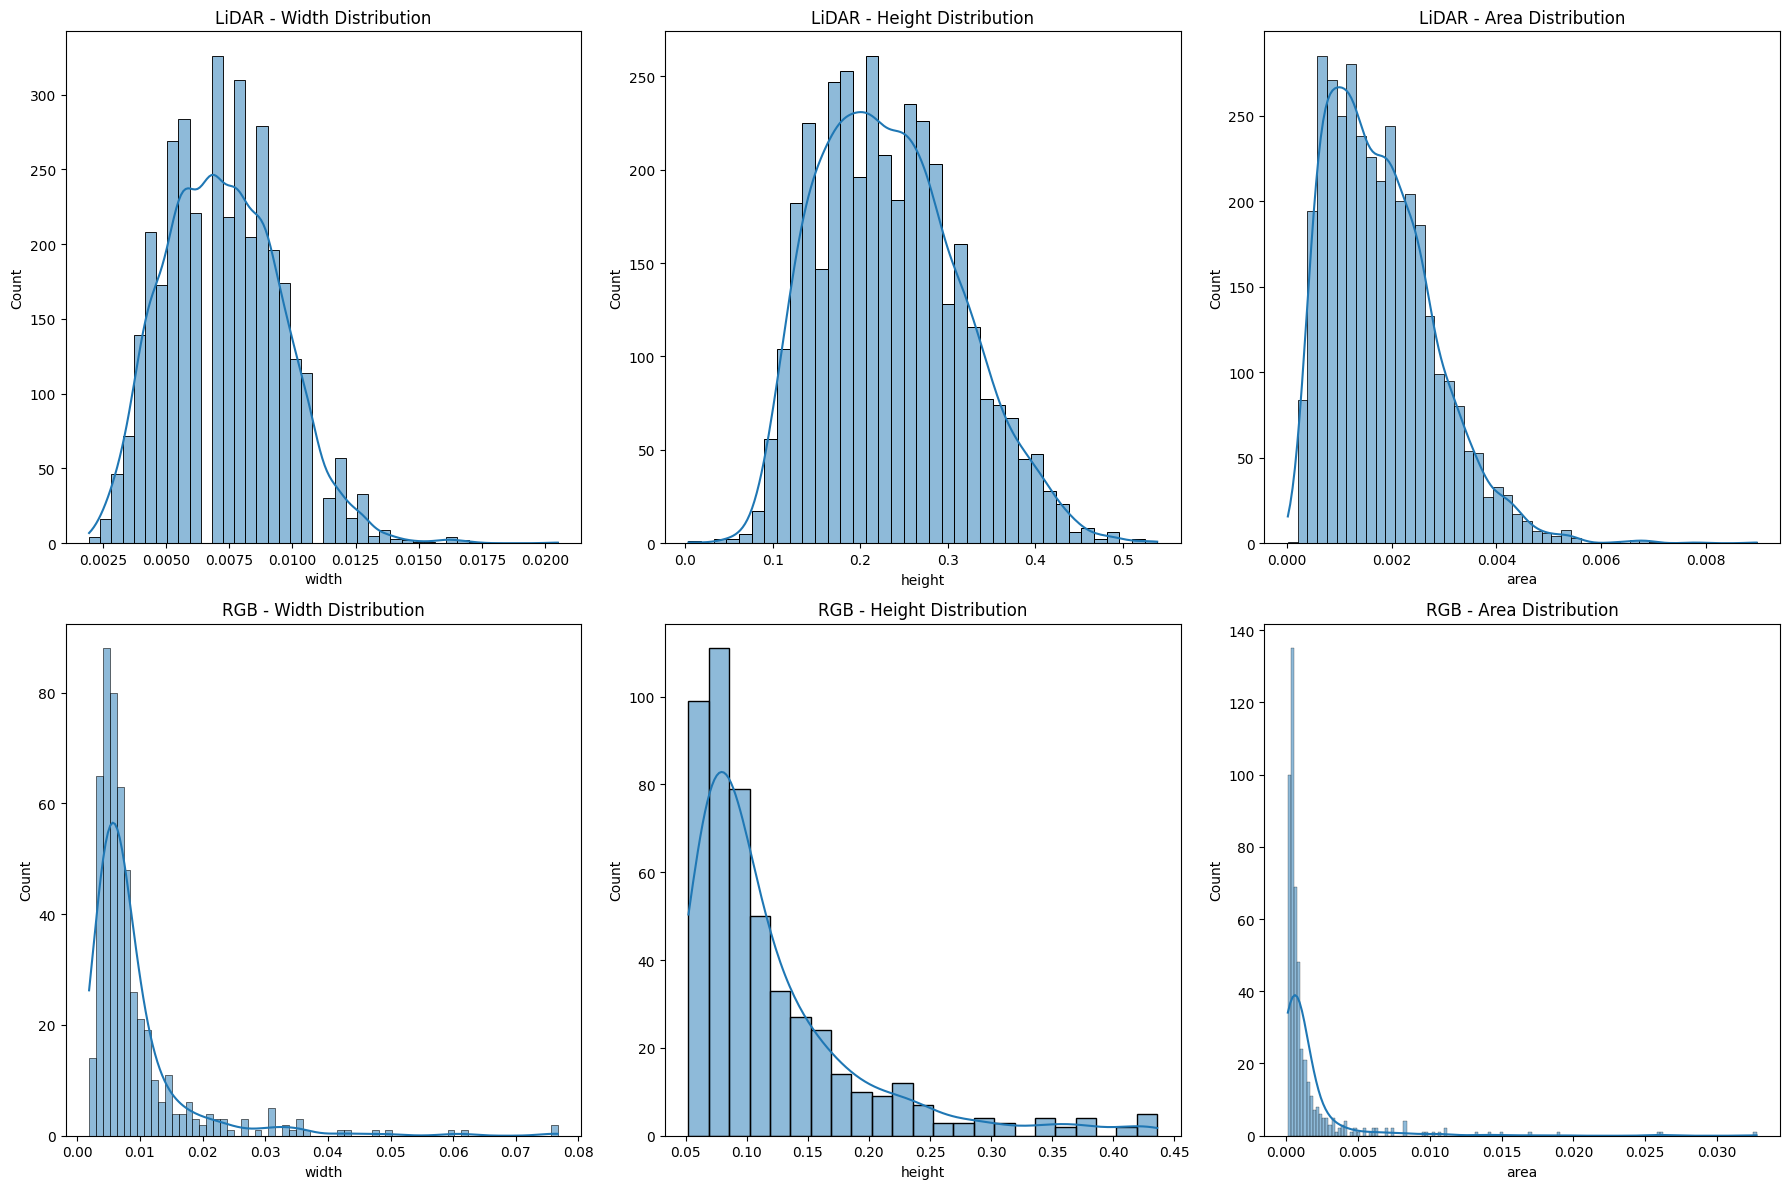

In [11]:
# Plot distributions
try:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # LiDAR distributions
    if not lidar_bbox_stats.empty:
        sns.histplot(lidar_bbox_stats['width'], kde=True, ax=axes[0, 0])
        axes[0, 0].set_title('LiDAR - Width Distribution')
        
        sns.histplot(lidar_bbox_stats['height'], kde=True, ax=axes[0, 1])
        axes[0, 1].set_title('LiDAR - Height Distribution')
        
        sns.histplot(lidar_bbox_stats['area'], kde=True, ax=axes[0, 2])
        axes[0, 2].set_title('LiDAR - Area Distribution')
    
    # RGB distributions
    if not rgb_bbox_stats.empty:
        sns.histplot(rgb_bbox_stats['width'], kde=True, ax=axes[1, 0])
        axes[1, 0].set_title('RGB - Width Distribution')
        
        sns.histplot(rgb_bbox_stats['height'], kde=True, ax=axes[1, 1])
        axes[1, 1].set_title('RGB - Height Distribution')
        
        sns.histplot(rgb_bbox_stats['area'], kde=True, ax=axes[1, 2])
        axes[1, 2].set_title('RGB - Area Distribution')
    
    plt.tight_layout()
except Exception as e:
    print(f"Error plotting bounding box distributions: {e}")

### 4.2 Bounding Box Position Heatmap

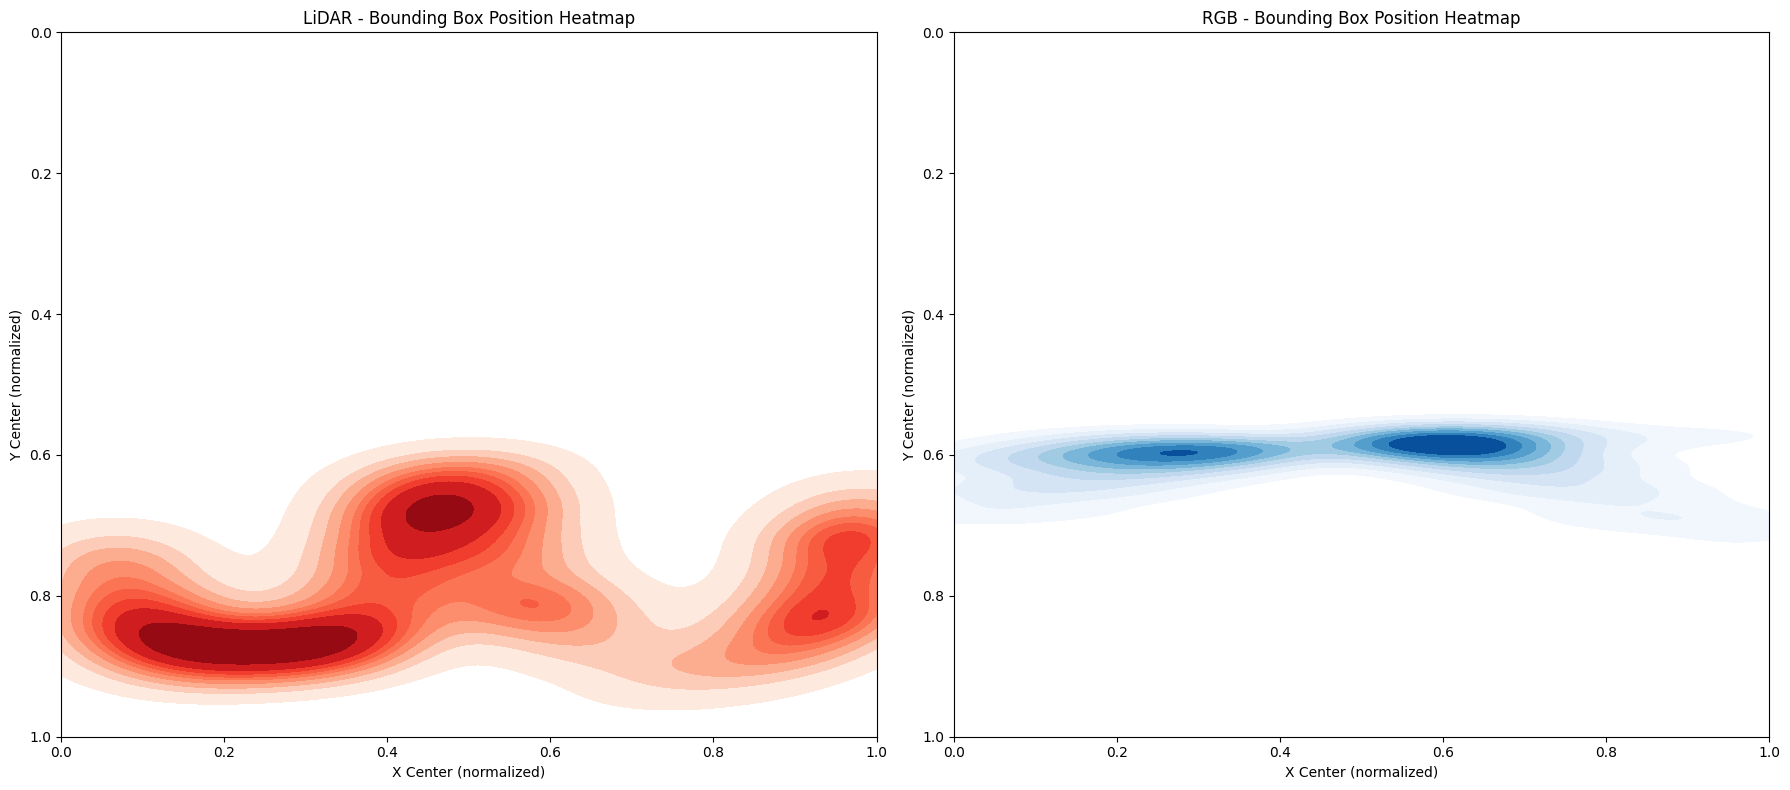

In [12]:
# Plot bounding box center positions
try:
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # LiDAR heatmap
    if not lidar_bbox_stats.empty:
        sns.kdeplot(x=lidar_bbox_stats['x_center'], y=lidar_bbox_stats['y_center'], 
                   cmap="Reds", fill=True, ax=axes[0])
        axes[0].set_title('LiDAR - Bounding Box Position Heatmap')
        axes[0].set_xlim(0, 1)
        axes[0].set_ylim(0, 1)
        axes[0].set_xlabel('X Center (normalized)')
        axes[0].set_ylabel('Y Center (normalized)')
        axes[0].invert_yaxis()  # Invert y-axis to match image coordinates
    
    # RGB heatmap
    if not rgb_bbox_stats.empty:
        sns.kdeplot(x=rgb_bbox_stats['x_center'], y=rgb_bbox_stats['y_center'], 
                   cmap="Blues", fill=True, ax=axes[1])
        axes[1].set_title('RGB - Bounding Box Position Heatmap')
        axes[1].set_xlim(0, 1)
        axes[1].set_ylim(0, 1)
        axes[1].set_xlabel('X Center (normalized)')
        axes[1].set_ylabel('Y Center (normalized)')
        axes[1].invert_yaxis()  # Invert y-axis to match image coordinates
    
    plt.tight_layout()
except Exception as e:
    print(f"Error plotting bounding box position heatmaps: {e}")

## 5. Image Characteristics Analysis

Let's analyze the image characteristics like brightness, contrast, and color distribution.

In [13]:
def analyze_image_characteristics(img_dir, num_samples=500):
    """Analyze image characteristics"""
    # Lists to store data
    brightness = []
    contrast = []
    avg_rgb = []
    image_sizes = []
    
    # Get all image files from all splits
    all_images = []
    for split_dir in [d for d in img_dir.iterdir() if d.is_dir()]:
        all_images.extend(list(split_dir.glob('*.jpg')) + list(split_dir.glob('*.jpeg')) + list(split_dir.glob('*.png')) + list(split_dir.glob('*.PNG')))
    
    # Sample images
    if all_images:
        sample_images = random.sample(all_images, min(num_samples, len(all_images)))
        
        for img_path in sample_images:
            # Read image
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Calculate brightness (average pixel value)
            brightness.append(np.mean(img))
            
            # Calculate contrast (standard deviation of pixel values)
            contrast.append(np.std(img))
            
            # Calculate average RGB values
            avg_rgb.append(np.mean(img, axis=(0, 1)))
            
            # Image size
            image_sizes.append(img.shape[:2])
    
    # Create DataFrame
    data = {
        'brightness': brightness,
        'contrast': contrast,
        'image_height': [size[0] for size in image_sizes],
        'image_width': [size[1] for size in image_sizes],
        'avg_red': [rgb[0] for rgb in avg_rgb],
        'avg_green': [rgb[1] for rgb in avg_rgb],
        'avg_blue': [rgb[2] for rgb in avg_rgb]
    }
    
    return pd.DataFrame(data)

# Analyze image characteristics
try:
    if LIDAR_IMG_DIR.exists():
        print("Analyzing LiDAR image characteristics...")
        lidar_img_stats = analyze_image_characteristics(LIDAR_IMG_DIR)
        print("LiDAR Image Characteristics:")
        print(lidar_img_stats.describe())
    
    if RGB_IMG_DIR.exists():
        print("\nAnalyzing RGB image characteristics...")
        rgb_img_stats = analyze_image_characteristics(RGB_IMG_DIR)
        print("RGB Image Characteristics:")
        print(rgb_img_stats.describe())
except Exception as e:
    print(f"Error analyzing image characteristics: {e}")

Analyzing LiDAR image characteristics...
LiDAR Image Characteristics:
       brightness    contrast  image_height  image_width     avg_red  \
count  500.000000  500.000000         500.0        500.0  500.000000   
mean   116.036854   80.644694         128.0       1024.0   45.464889   
std      9.889291    3.583091           0.0          0.0   23.877180   
min     92.507141   71.749348         128.0       1024.0    4.673943   
25%    108.007270   78.294856         128.0       1024.0   27.427357   
50%    113.932973   80.272813         128.0       1024.0   42.654301   
75%    124.071940   82.882960         128.0       1024.0   65.288294   
max    140.797295   88.168604         128.0       1024.0   99.840599   

        avg_green    avg_blue  
count  500.000000  500.000000  
mean   145.442547  157.203125  
std     10.542532    7.812457  
min     88.863007  118.645020  
25%    139.185692  154.167879  
50%    146.364063  157.161560  
75%    152.989618  160.285688  
max    166.701675  185.83

## 6. Conclusion and Next Steps

Based on the exploratory data analysis, here are some insights and recommended next steps:

### Insights
1. **Dataset Size**: [Fill in after running the notebook]
2. **Label Distribution**: [Fill in after running the notebook]
3. **Image Characteristics**: [Fill in after running the notebook]
4. **Bounding Box Properties**: [Fill in after running the notebook]

### Next Steps
1. **Data Preprocessing**: Based on the observed characteristics, develop appropriate preprocessing strategies for both LiDAR and RGB datasets.
2. **Data Augmentation**: Design augmentation techniques specifically tailored to snow pole detection (e.g., contrast enhancement, rotation, etc.).
3. **Model Selection**: Choose appropriate YOLO variants based on the observed box sizes and distributions.
4. **Transfer Learning**: Start from pretrained models and fine-tune for this specific task.
5. **Model Evaluation**: Track performance metrics (Precision, Recall, mAP) on validation set during training.